# **Shopping Mall Customer Segmentation**

The dataset comprises customer information including Customer ID, age, gender, annual income, and spending score. Spending score is determined by analyzing customer behavior and purchasing data. It aids in understanding customer segmentation for strategic marketing decisions.

[Kaggle link](https://www.kaggle.com/datasets/zubairmustafa/shopping-mall-customer-segmentation-data)

### **Importing the dependencies**

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

### **Data collection and Analysis**

In [2]:
# Loading data from csv file to a pandas dataframe
customer_df = pd.read_csv('Shopping Mall Customer Segmentation Data .csv')

In [3]:
# First 5 rows in the dataframe
customer_df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [4]:
# Getting information about the dataset
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer ID     15079 non-null  str  
 1   Age             15079 non-null  int64
 2   Gender          15079 non-null  str  
 3   Annual Income   15079 non-null  int64
 4   Spending Score  15079 non-null  int64
dtypes: int64(3), str(2)
memory usage: 589.2 KB


In [5]:
# Getting statistical information about the dataset
customer_df.describe()

,Age,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617
std,21.119207,52249.425866,28.726977
min,18.000000,20022.000000,1.000000
25%,36.000000,64141.000000,26.000000
50%,54.000000,109190.000000,51.000000
75%,72.000000,155008.000000,75.000000
max,90.000000,199974.000000,100.000000


In [6]:
# Checking for missing values
customer_df.isna().sum()

Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

In [7]:
# Checking for duplicate values
customer_df.duplicated().sum()

np.int64(0)

### **Feature Engineering**

In [8]:
# Checking unique gender values
customer_df['Gender'].value_counts()

Gender
Male      7595
Female    7484
Name: count, dtype: int64

In [9]:
customer_df.drop(['Customer ID','Gender'], axis=1, inplace=True)

In [10]:
# Scaling the features
scaler = StandardScaler()
customer_df_scaled = scaler.fit_transform(customer_df)


### **Choosing the number of clusters**

In [11]:
# Finding sum of squared distances of each point to its cluster centroid, for different number of clusters
l1 = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=101)
    kmeans.fit(customer_df_scaled)

    l1.append(kmeans.inertia_)

Text(0.5, 1.0, 'Clusters vs Inertia')

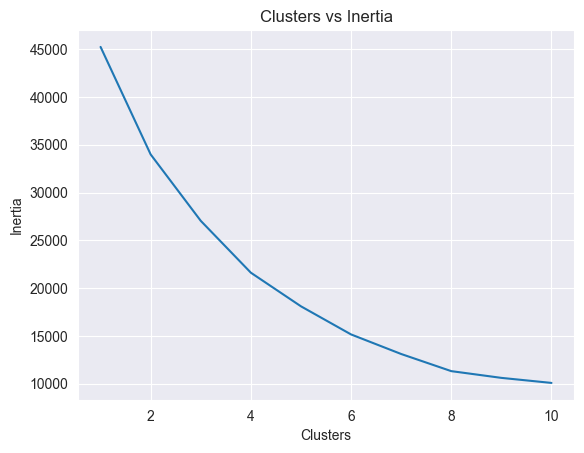

In [12]:
# Elbow graph
sns.set_style('darkgrid')
plt.plot(range(1,11), l1)
plt.ylabel('Inertia')
plt.xlabel('Clusters')
plt.title('Clusters vs Inertia')

In [13]:
# Calculating the silhoutte score to verify the best cluster number

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=101)
    labels = kmeans.fit_predict(customer_df_scaled)
    print('cluster = ',i,'silhouette_score = ',round(silhouette_score(customer_df_scaled,labels),3))

cluster =  2 silhouette_score =  0.241
cluster =  3 silhouette_score =  0.239
cluster =  4 silhouette_score =  0.269
cluster =  5 silhouette_score =  0.263
cluster =  6 silhouette_score =  0.281
cluster =  7 silhouette_score =  0.28
cluster =  8 silhouette_score =  0.28
cluster =  9 silhouette_score =  0.289
cluster =  10 silhouette_score =  0.275


**Observing the Elbow graph and the silhoutte scores the optimal number of clusters = 5**

### **Training the Kmeans clustering model**

In [26]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=101)

y = kmeans.fit_predict(customer_df_scaled)

### **Visualizing the clusters**

In [29]:
# Creating two principal components from the dataset for visualisation
pca = PCA(n_components=3)
X_pca = pca.fit_transform(customer_df_scaled)

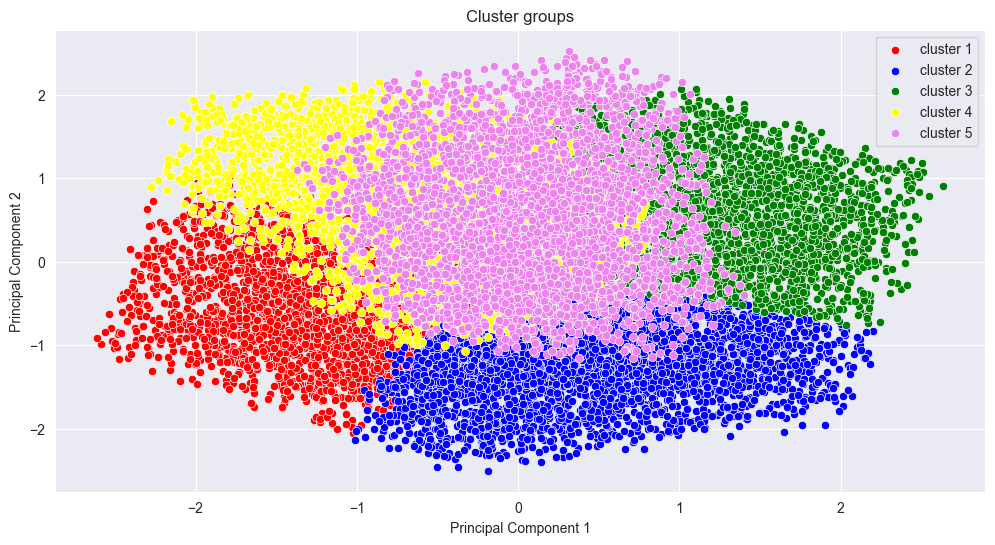

In [28]:
plt.figure(figsize=(12,6))

sns.scatterplot(x=X_pca[y==0,0], y=X_pca[y==0,1], color='red', label='cluster 1')
sns.scatterplot(x=X_pca[y==1,0], y=X_pca[y==1,1], color='blue', label='cluster 2')
sns.scatterplot(x=X_pca[y==2,0], y=X_pca[y==2,1], color='green', label='cluster 3')
sns.scatterplot(x=X_pca[y==3,0], y=X_pca[y==3,1], color='yellow', label='cluster 4')
sns.scatterplot(x=X_pca[y==4,0], y=X_pca[y==4,1], color='violet', label='cluster 5')

plt.title('Cluster groups')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

### **Naming the labels**

In [30]:
customer_df['Clusters'] = y

In [31]:
customer_df.groupby('Clusters').mean()

,Age,Annual Income,Spending Score
Clusters,,,
0,36.987067,66615.338532,72.829593
1,54.643564,62384.645065,23.507351
2,71.348620,154266.910142,29.104400
3,34.379950,158334.498762,51.684097
4,73.467374,108108.709335,77.412114


- Cluster 0: Mid-Income High Spenders
- Cluster 1: Older Low Spenders
- Cluster 2: Wealthy Conservative Seniors
- Cluster 3: Young High-Income Moderate Spenders
- Cluster 4: Senior Premium Customers

## **Conclusion**

In this project, customer data consisting of Age, Annual Income, and Spending Score was analyzed to identify meaningful customer segments using K-Means clustering. The goal was to understand customer behavior patterns and support data-driven marketing strategies.

After preprocessing and feature selection, five distinct customer segments were identified:

- **Mid-Income High Spenders**  
  Customers with moderate income but high spending behavior.  
  Ideal targets for promotions, discounts, and loyalty programs.

- **Older Low Spenders**  
  Older customers with low spending despite moderate income.  
  Less responsive to marketing; focus on essential-value offerings.

- **Wealthy Conservative Seniors**  
  High-income senior customers with low spending patterns.  
  High potential segment; can be targeted with personalized premium offers.

- **Young High-Income Moderate Spenders**  
  Younger customers with high income and moderate spending.  
  Suitable for upselling and premium product marketing.

- **Senior Premium Customers**  
  Older customers with high income and high spending behavior.  
  Most valuable segment; focus on retention and exclusive services.